# Proyecto final de aprendizaje automático

In [58]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

## Paso 1: Definición del problema

### Objetivo: 
- Predecir la demanda futura de productos farmacéuticos para optimizar la gestión de inventario.
- Evitar quiebres de stock y sobrestock. 
- Reducir pérdida por vencimientos y mejorar disponibilidad.
##### Plan B: Predecir el total que abonará el cliente en una transacción, considerando cantidad, producto, rubro, cobertura, descuentos e impuestos.

## Paso 2: Obtencion y carga del conjunto de datos

In [59]:
df = pd.read_csv('../data/raw/farmacia-datos.csv', sep=';',encoding='latin-1')
df.head(12)

,Fecha,Tipo Mov.,Fac. Tipo,Fac. Suc.,Fac. Nun.,Fisc. Numero,Tipo Pago,Cant.,Precio,Producto,Sub. Total,Rubro,Cobertura,Ajustes,Desc. Adic.,Total. Cliente,IVA,Tasa Iva,Total Gravado,Total sin Gravar
0,01/01/25 01.13.46,F,B,0,379923,NaN,E,1,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,0,9344,0,0,0,9344
1,01/01/25 01.59.21,F,B,0,379924,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,0,"5142,11",0,0,0,"8174,96"
2,01/01/25 02.01.59,F,B,0,379925,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,0,"2856,86",0,0,0,"8174,96"
3,01/01/25 02.04.14,F,B,0,379926,NaN,E,1,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,0,"8086,82",0,0,0,"8086,82"
4,01/01/25 02.08.35,F,B,0,379927,NaN,E,1,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,0,"26750,12",0,0,0,"26750,12"
5,01/01/25 06.06.42,F,B,0,379928,NaN,E,1,"24480,51",EVATEST DIGITAL env.x 1,"24480,51",FARMACIA,0,0,0,"24480,51","4248,683554",21,"20231,82645",0
6,01/01/25 06.22.37,F,B,0,379929,NaN,E,1,4800,GEN LP KETOROLAC blister 20 mg x 10,4800,FARMACIA,0,0,0,4800,0,0,0,4800
7,01/01/25 06.22.37,F,B,0,379929,NaN,E,1,4961,CAFIASPIRINA PLUS comp.x 20,4961,FARMACIA,0,0,0,4961,0,0,0,4961
8,01/01/25 07.46.36,F,B,0,379930,NaN,E,2,3500,ACCESORIO (unica),7000,FARMACIA,0,0,0,7000,"1214,876033",21,"5785,123967",0
9,02/01/25 08.08.38,F,B,0,379931,NaN,E,1,3430,QURA PLUS comp.rec.x 20,3430,FARMACIA,0,0,343,3087,0,0,0,3430


> Los datos provienen de un archivo Excel extraído del sistema de facturación de una farmacia real, convertido posteriormente a formato CSV para su procesamiento.

## Paso 3: Almacenar la información

In [60]:
df.columns = df.columns.str.replace('.', '', regex=False).str.replace(' ', '_')

Para la ejecución de las consultas SQL se normalizaron los nombres de columnas para garantizar la correcta agregación de variables numéricas.

In [61]:
# Create connection to SQLite
conn = sqlite3.connect('farmacia-datos.db')

In [62]:
# Save table
df.to_sql('ventas', conn, if_exists='replace', index=False)

117415

In [63]:
# Verify that the table exists
query = 'SELECT * FROM ventas LIMIT 5;'
pd.read_sql(query, conn)

,Fecha,Tipo_Mov,Fac_Tipo,Fac_Suc,Fac_Nun,Fisc_Numero,Tipo_Pago,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Ajustes,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar
0,01/01/25 01.13.46,F,B,0,379923,None,E,1,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,0,9344,0,0,0,9344
1,01/01/25 01.59.21,F,B,0,379924,None,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,0,"5142,11",0,0,0,"8174,96"
2,01/01/25 02.01.59,F,B,0,379925,None,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,0,"2856,86",0,0,0,"8174,96"
3,01/01/25 02.04.14,F,B,0,379926,None,E,1,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,0,"8086,82",0,0,0,"8086,82"
4,01/01/25 02.08.35,F,B,0,379927,None,E,1,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,0,"26750,12",0,0,0,"26750,12"


**Top 10 productos más vendidos**

In [64]:
# Execute a real SQL query
query_top_10 = '''
SELECT Producto, SUM("Cant") AS Demanda_total
FROM ventas
GROUP BY Producto
ORDER BY Demanda_total DESC
LIMIT 10;
'''
pd.read_sql(query_top_10, conn)

,Producto,Demanda_total
0,BUSCAPINA COMPOSITUM comp.rec.x 20,2648
1,QURA PLUS comp.rec.x 20,2602
2,GEN LP IBUPROFENO blister 600 mg x 10,2135
3,SERTAL COMPUESTO comp.rec.x 20,1786
4,GEN LP OMEPRAZOL blister 20 mg x 15,1576
5,ALIKAL (unica),1483
6,MYLANTA EXTRA comp.mast.x 24,1278
7,ASPIRINA PREVENT comp.cub.enterica x 50,1160
8,CAFIASPIRINA comp.x 30,1041
9,TAFIROL 1G X 8 (unica),983


> Se almacenaron los datos en una base de datos SQLite y se realizaron consultas SQL desde Python para identificar productos de alta rotación y patrones de demanda.

**Demanda total por producto**

In [65]:
query_product = '''
SELECT Producto, SUM("Cant") AS Demanda_total
FROM ventas
GROUP BY Producto;
'''
pd.read_sql(query_product, conn)

,Producto,Demanda_total
0,None,1
1,CHUP.MANZANITA(C/DIBUJO)T/SILIC.+3M RED - ES...,1
2,(unica),4
3,1,1
4,1 1,7
...,...,...
7671,q,1
7672,|,1
7673,º,3
7674,ÓLEO Calcáreo x 240 ml.,1


Esta consulta permite identificar los productos con mayor volumen de ventas acumuladas, fundamentales para la gestión de stock y la priorización de reposición.

**Demanda agregada por día**

In [66]:
query_per_day = """
SELECT strftime('%Y-%m', Fecha) AS mes, SUM("Cant") AS Demanda_mensual
FROM ventas
GROUP BY mes
ORDER BY mes;
"""

pd.read_sql(query_per_day, conn)

,mes,Demanda_mensual
0,None,160639


La agregación diaria por producto permite modelar la demanda como una serie temporal, base para la predicción de consumo futuro.

In [67]:
query_coverage = """
SELECT Cobertura, SUM("Cant") AS Demanda_total
FROM ventas
GROUP BY Cobertura;
"""
pd.read_sql(query_coverage, conn)


,Cobertura,Demanda_total
0,"-157953,92",1
1,0,107170
2,10000,1
3,"10000,188",1
4,"10001,04",3
...,...,...
23016,"9993,308",1
23017,"9995,3",3
23018,"9998,392",2
23019,"9998,952",1


La presencia de cobertura médica incrementa la demanda, lo cual debe considerarse en la planificación de inventario.

## Paso 4: Realiza un análisis descriptivo

Variable clave: `Cant`

In [68]:
df['Cant'].describe()

count    117415.000000
mean          1.368130
std           1.862115
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         106.000000
Name: Cant, dtype: float64

In [69]:
media = df['Cant'].mean()
mediana = df['Cant'].median()
moda = df['Cant'].mode()[0]
varianza = df['Cant'].var()
asimetria = df['Cant'].skew()

In [70]:
print(f'Media:     {media:.2f}')
print(f'Mediana:   {mediana:.2f}')
print(f'Moda:      {moda:.2f}')
print(f'Varianza:  {varianza:.2f}')
print(f'Asimetría: {asimetria:.2f}')

Media:     1.37
Mediana:   1.00
Moda:      1.00
Varianza:  3.47
Asimetría: 12.14


- **Media** (1.37) vs **Mediana** (1.00): El hecho de que la media sea mayor que la mediana indica que la distribución está sesgada a la derecha. Mientras que la mayoría de los clientes compran solo 1 unidad (mediana), hay un grupo pequeño de transacciones con cantidades muy altas que elevan el promedio.
- **Moda** (1.00): Es el valor más frecuente. Esto confirma que el comportamiento estándar en la farmacia es la compra de una única unidad por producto (típico de medicamentos bajo receta).
- **Varianza** (3.47): La desviación estándar sería la raíz cuadrada de esto (≈1.86). Aunque la mayoría compra 1 unidad, hay una variabilidad considerable. En términos de negocio, esto sugiere que conviven dos tipos de clientes: el consumidor final (compra 1 unidad) y posiblemente clientes institucionales o crónicos (compran varias cajas o tratamientos completos).
- **Asimetría Positiva Extrema**: Un valor de 12.14 es extremadamente alto (en una distribución normal sería 0).   

Debido a esta asimetría, será necesario decidir si se eliminan esos valores extremos para entrenar el modelo de Machine Learning o si se tratan de forma especial, ya que podrían distorsionar las predicciones.

In [71]:
products_no_name = df[df['Producto'].str.len() <= 4]['Producto'].unique()
products_no_name

array(['1 1', 'A1 1', '5200', 'º', '|', 'LIMA', 'q', '1'], dtype=object)

In [72]:
df.shape

(117415, 20)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117415 entries, 0 to 117414
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Fecha             117415 non-null  object 
 1   Tipo_Mov          117415 non-null  object 
 2   Fac_Tipo          117415 non-null  object 
 3   Fac_Suc           117415 non-null  int64  
 4   Fac_Nun           117415 non-null  int64  
 5   Fisc_Numero       0 non-null       float64
 6   Tipo_Pago         117415 non-null  object 
 7   Cant              117415 non-null  int64  
 8   Precio            117415 non-null  object 
 9   Producto          117414 non-null  object 
 10  Sub_Total         117415 non-null  object 
 11  Rubro             117415 non-null  object 
 12  Cobertura         117415 non-null  object 
 13  Ajustes           117415 non-null  int64  
 14  Desc_Adic         117415 non-null  object 
 15  Total_Cliente     117415 non-null  object 
 16  IVA               11

In [74]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Fac_Suc,117415.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Fac_Nun,117415.0,417643.591407,22420.160070,379923.0,398031.0,416281.0,437618.5,455865.0
Fisc_Numero,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cant,117415.0,1.368130,1.862115,0.0,1.0,1.0,1.0,106.0
Ajustes,117415.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Tasa_Iva,117415.0,4.090363,8.316679,0.0,0.0,0.0,0.0,21.0


In [75]:
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%y %H.%M.%S')

In [76]:
df.head(5)

,Fecha,Tipo_Mov,Fac_Tipo,Fac_Suc,Fac_Nun,Fisc_Numero,Tipo_Pago,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Ajustes,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar
0,2025-01-01 01:13:46,F,B,0,379923,NaN,E,1,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,0,9344,0,0,0,9344
1,2025-01-01 01:59:21,F,B,0,379924,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,0,"5142,11",0,0,0,"8174,96"
2,2025-01-01 02:01:59,F,B,0,379925,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,0,"2856,86",0,0,0,"8174,96"
3,2025-01-01 02:04:14,F,B,0,379926,NaN,E,1,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,0,"8086,82",0,0,0,"8086,82"
4,2025-01-01 02:08:35,F,B,0,379927,NaN,E,1,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,0,"26750,12",0,0,0,"26750,12"


In [77]:
df.duplicated().sum()

np.int64(121)

In [78]:
duplicated = df[df.duplicated(keep=False)]
duplicated

,Fecha,Tipo_Mov,Fac_Tipo,Fac_Suc,Fac_Nun,Fisc_Numero,Tipo_Pago,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Ajustes,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar
2122,2025-01-07 14:56:11,F,B,0,381215,NaN,E,1,3200,IMPULSE VERY PINK BS AERO 150,3200,PERFUMERIA,0,0,0,3200,"555,3719008",21,"2644,628099",0
2123,2025-01-07 14:56:11,F,B,0,381215,NaN,E,1,3200,IMPULSE VERY PINK BS AERO 150,3200,PERFUMERIA,0,0,0,3200,"555,3719008",21,"2644,628099",0
2124,2025-01-07 14:56:11,F,B,0,381215,NaN,E,1,3200,IMPULSE VERY PINK BS AERO 150,3200,PERFUMERIA,0,0,0,3200,"555,3719008",21,"2644,628099",0
4858,2025-01-14 16:00:35,F,B,0,382867,NaN,E,1,"21971,64",MEMANTINA RICHET 10 mg comp.x 30,"21971,64",FARMACIA,"10985,82",0,0,"10985,82",0,0,0,"21971,64"
4859,2025-01-14 16:00:35,F,B,0,382867,NaN,E,1,"21971,64",MEMANTINA RICHET 10 mg comp.x 30,"21971,64",FARMACIA,"10985,82",0,0,"10985,82",0,0,0,"21971,64"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112196,2025-12-06 11:10:48,F,B,0,452638,NaN,E,1,"8157,79",TAFIROL PLUS RAPIDA ACCION cáps.bl. x 16,"8157,79",FARMACIA,0,0,0,"8157,79",0,0,0,"8157,79"
114299,2025-12-13 09:11:38,F,B,0,453912,NaN,E,1,9358,LOTRIAL 10 mg comp.x 30,9358,FARMACIA,0,0,0,9358,0,0,0,9358
114300,2025-12-13 09:11:38,F,B,0,453912,NaN,E,1,9358,LOTRIAL 10 mg comp.x 30,9358,FARMACIA,0,0,0,9358,0,0,0,9358
115321,2025-12-16 16:31:39,F,B,0,454552,NaN,E,1,"9641,696",BAGOVIT CAPILAR PLASMA VEG 350,"9641,696",PERFUMERIA,0,0,0,"9641,696","1673,352198",21,"7968,343802",0


### Limpieza de datos: Eliminar información irrelevante

In [79]:
df['Fisc_Numero'].isna().sum()

np.int64(117415)

In [80]:
(df['Fac_Suc'] == 0).sum()

np.int64(117415)

In [81]:
df['Tipo_Mov'].unique()

array(['F'], dtype=object)

In [82]:
df['Fac_Tipo'].value_counts(dropna=False)

Fac_Tipo
B    117251
A       164
Name: count, dtype: int64

In [83]:
df['IVA'].value_counts(dropna=False)

IVA
0              94545
173,553719       982
520,661157       673
867,768595       658
780,9917355      641
               ...  
2965,42562         1
225,3775537        1
1662,644628        1
4947,476569        1
491,7738347        1
Name: count, Length: 4217, dtype: int64

In [84]:
df['Tasa_Iva'].value_counts(dropna=False)

Tasa_Iva
0     94545
21    22870
Name: count, dtype: int64

In [85]:
df['Tipo_Pago'].value_counts(dropna=False)

Tipo_Pago
E    117415
Name: count, dtype: int64

In [86]:
df['Ajustes'].value_counts(dropna=False)

Ajustes
0    117415
Name: count, dtype: int64

In [87]:
df['Desc_Adic'].value_counts(dropna=False)

Desc_Adic
0             115273
-3,64E-12        226
-1,82E-12         86
-7,28E-12         79
-9,09E-13         24
               ...  
1450               1
8741,37096         1
4704,488           1
231,56             1
1148               1
Name: count, Length: 1155, dtype: int64

- La variable `Fisc_Numero` no aporta información al análisis, ya que presenta un 100% de valores nulos (0 non-null). Al no contener observaciones válidas, se elimina del dataset para evitar ruido y simplificar el análisis.
- Las variables `Fac_Suc`,`Tipo_Mov`, `Tipo_Pago`, `Ajustes`  presentan un único valor en la totalidad de los registros. Al no mostrar variabilidad, no aporta información relevante para el análisis ni para modelos posteriores, por lo que se eliminan del dataset.

In [88]:
df.drop(['Fisc_Numero', 'Fac_Suc', 'Tipo_Mov', 'Tipo_Pago', 'Ajustes'], axis=1, inplace=True)
df

,Fecha,Fac_Tipo,Fac_Nun,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar
0,2025-01-01 01:13:46,B,379923,1,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,9344,0,0,0,9344
1,2025-01-01 01:59:21,B,379924,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,"5142,11",0,0,0,"8174,96"
2,2025-01-01 02:01:59,B,379925,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,"2856,86",0,0,0,"8174,96"
3,2025-01-01 02:04:14,B,379926,1,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,"8086,82",0,0,0,"8086,82"
4,2025-01-01 02:08:35,B,379927,1,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,"26750,12",0,0,0,"26750,12"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117410,2025-12-23 10:23:06,B,455861,1,5000,COLGATE (unica),5000,FARMACIA,0,0,5000,0,0,0,5000
117411,2025-12-23 10:25:57,B,455862,1,"13641,2",TAFIROL 1 G comp.ran.x 50,"13641,2",FARMACIA,"5808,98",0,"7832,22",0,0,0,"13641,2"
117412,2025-12-23 10:34:31,B,455863,1,16000,CICATRICURE GEL Gel NF x 30 g,16000,FARMACIA,0,0,16000,"2776,859504",21,"13223,1405",0
117413,2025-12-23 10:38:49,B,455864,1,"36758,39",LOUTEN T colirio x 2.5 ml,"36758,39",FARMACIA,"14703,36",0,"22055,03",0,0,0,"36758,39"


### Análisis de Variables

In [89]:
numerical_variables = df.select_dtypes(include=['int64', 'float64'])
numerical_variables

,Fac_Nun,Cant,Tasa_Iva
0,379923,1,0
1,379924,1,0
2,379925,1,0
3,379926,1,0
4,379927,1,0
...,...,...,...
117410,455861,1,0
117411,455862,1,0
117412,455863,1,21
117413,455864,1,0


In [90]:
categorical_variables = df.select_dtypes(include=['object'])
categorical_variables

,Fac_Tipo,Precio,Producto,Sub_Total,Rubro,Cobertura,Desc_Adic,Total_Cliente,IVA,Total_Gravado,Total_sin_Gravar
0,B,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,9344,0,0,9344
1,B,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,"5142,11",0,0,"8174,96"
2,B,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,"2856,86",0,0,"8174,96"
3,B,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,"8086,82",0,0,"8086,82"
4,B,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,"26750,12",0,0,"26750,12"
...,...,...,...,...,...,...,...,...,...,...,...
117410,B,5000,COLGATE (unica),5000,FARMACIA,0,0,5000,0,0,5000
117411,B,"13641,2",TAFIROL 1 G comp.ran.x 50,"13641,2",FARMACIA,"5808,98",0,"7832,22",0,0,"13641,2"
117412,B,16000,CICATRICURE GEL Gel NF x 30 g,16000,FARMACIA,0,0,16000,"2776,859504","13223,1405",0
117413,B,"36758,39",LOUTEN T colirio x 2.5 ml,"36758,39",FARMACIA,"14703,36",0,"22055,03",0,0,"36758,39"


In [91]:
columns_to_numeric = ['Precio', 'Sub_Total', 'Cobertura', 'Desc_Adic', 'Total_Cliente', 'IVA', 'Total_Gravado', 'Total_sin_Gravar']
df[columns_to_numeric] = df[columns_to_numeric].apply(pd.to_numeric, errors='coerce')

In [92]:
df.dtypes

Fecha               datetime64[ns]
Fac_Tipo                    object
Fac_Nun                      int64
Cant                         int64
Precio                     float64
Producto                    object
Sub_Total                  float64
Rubro                       object
Cobertura                  float64
Desc_Adic                  float64
Total_Cliente              float64
IVA                        float64
Tasa_Iva                     int64
Total_Gravado              float64
Total_sin_Gravar           float64
dtype: object

Varias variables se encontraban almacenadas como tipo object a pesar de representar valores numéricos. Se procedió a su conversión a tipo numérico y los valores no convertibles a NaN para su posterior tratamiento.

In [93]:
final_categorical_variables = df.select_dtypes(include=['object'])
final_categorical_variables

,Fac_Tipo,Producto,Rubro
0,B,ACTRON PEDIATRICO 4% susp.oral x 100 ml,FARMACIA
1,B,AMOXIDAL 500 mg comp.rec.x 21,FARMACIA
2,B,AMOXIDAL 500 mg comp.rec.x 21,FARMACIA
3,B,MUELITA FORTE GEL gel pomo x 10 g,FARMACIA
4,B,DIOXAFLEX B12 comp.x 20,FARMACIA
...,...,...,...
117410,B,COLGATE (unica),FARMACIA
117411,B,TAFIROL 1 G comp.ran.x 50,FARMACIA
117412,B,CICATRICURE GEL Gel NF x 30 g,FARMACIA
117413,B,LOUTEN T colirio x 2.5 ml,FARMACIA


Las variables categóricas son: `Fac_Tipo`, `Producto`, `Rubro`.

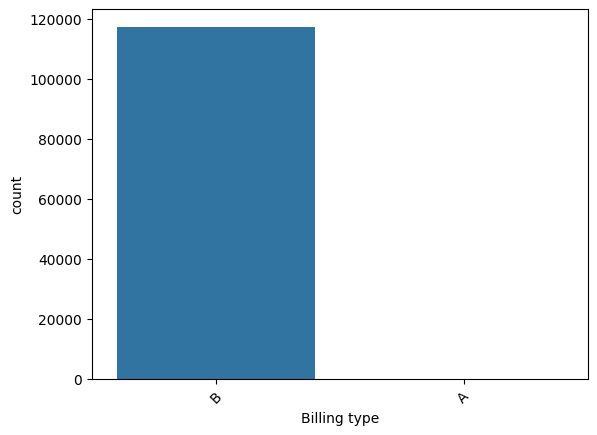

In [94]:
sns.countplot(data=df, x='Fac_Tipo')
plt.xlabel('Billing type')
plt.xticks(rotation=45)
plt.show()

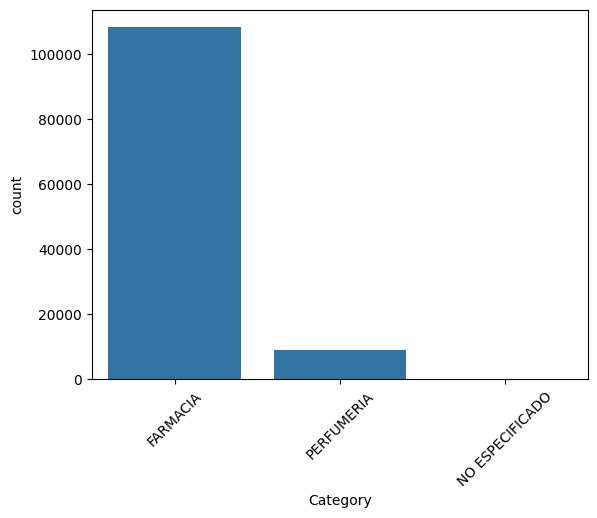

In [95]:
sns.countplot(data=df, x='Rubro')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.show()

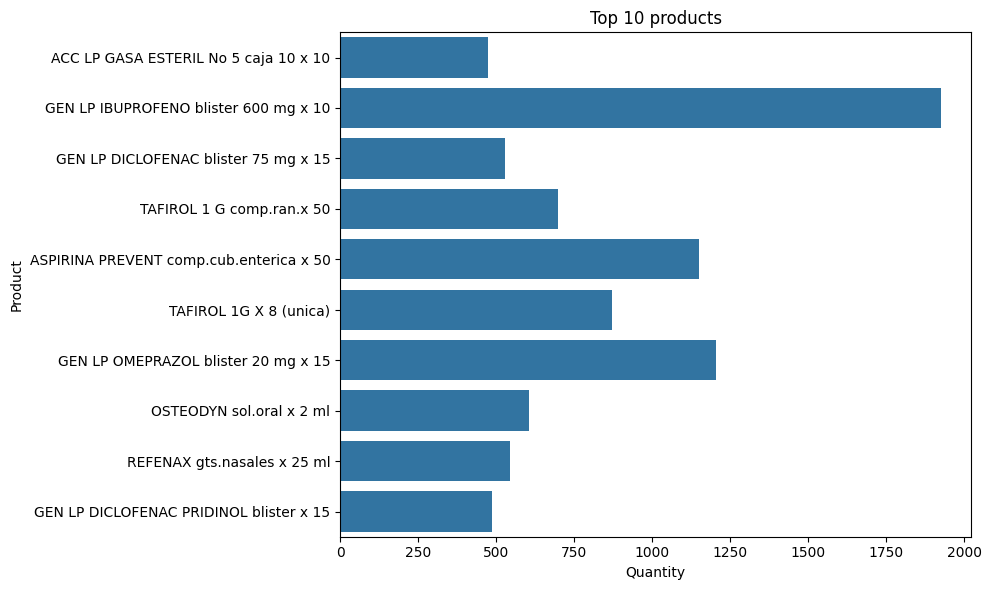

In [96]:
top_products = df['Producto'].value_counts().nlargest(10).index

plt.figure(figsize=(10, 6))
sns.countplot(data=df[df['Producto'].isin(top_products)],
              y='Producto')

plt.title(f'Top 10 products')
plt.xlabel('Quantity')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [97]:
final_numerical_variables = df.select_dtypes(include=['int64', 'float64'])
final_numerical_variables

,Fac_Nun,Cant,Precio,Sub_Total,Cobertura,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar
0,379923,1,9344.0,9344.0,0.0,0.0,9344.0,0.0,0,0.0,9344.0
1,379924,1,NaN,NaN,NaN,0.0,NaN,0.0,0,0.0,NaN
2,379925,1,NaN,NaN,NaN,0.0,NaN,0.0,0,0.0,NaN
3,379926,1,NaN,NaN,0.0,0.0,NaN,0.0,0,0.0,NaN
4,379927,1,NaN,NaN,0.0,0.0,NaN,0.0,0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
117410,455861,1,5000.0,5000.0,0.0,0.0,5000.0,0.0,0,0.0,5000.0
117411,455862,1,NaN,NaN,NaN,0.0,NaN,0.0,0,0.0,NaN
117412,455863,1,16000.0,16000.0,0.0,0.0,16000.0,NaN,21,NaN,0.0
117413,455864,1,NaN,NaN,NaN,0.0,NaN,0.0,0,0.0,NaN


Variables numéricas son: `Fac_Nun`, `Cant`, `Precio`, `Sub_Total`, `Cobertura`, `Desc_Adic`, `Total_Cliente`, `IVA`, `Tasa_Iva`, `Total_Gravado`, `Total_sin_Gravar`.

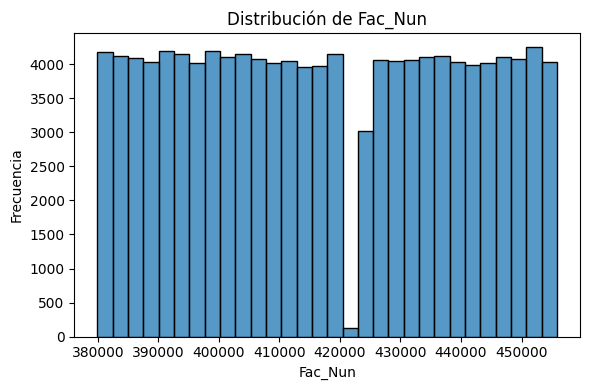

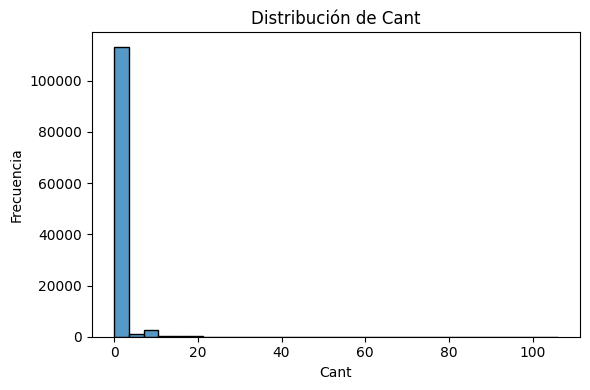

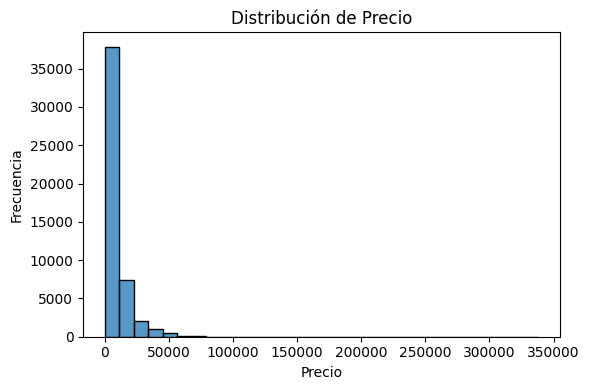

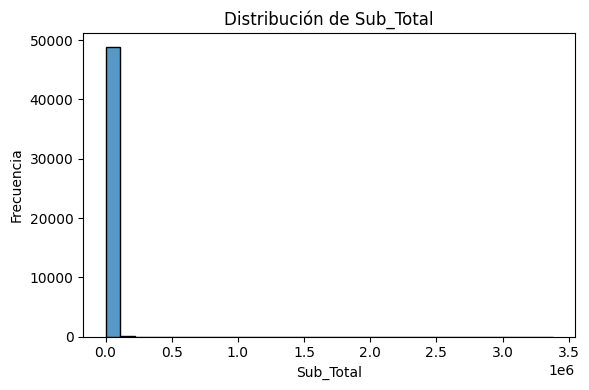

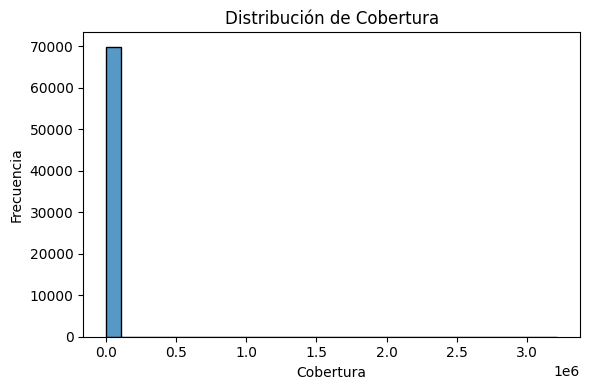

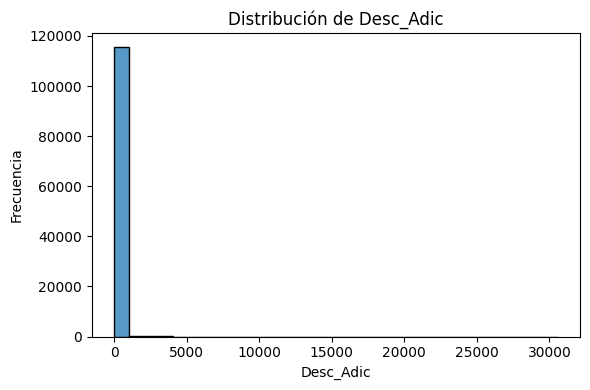

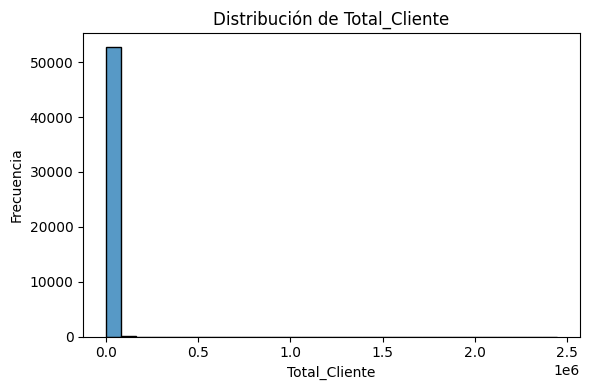

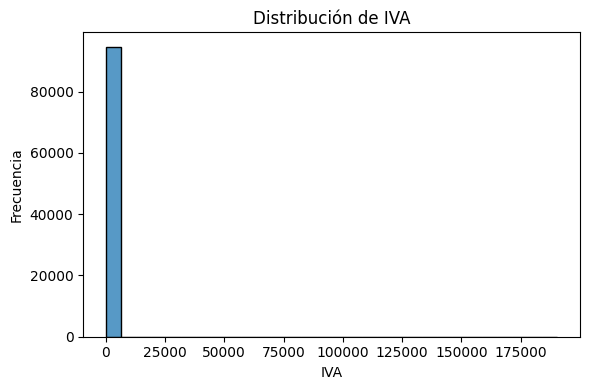

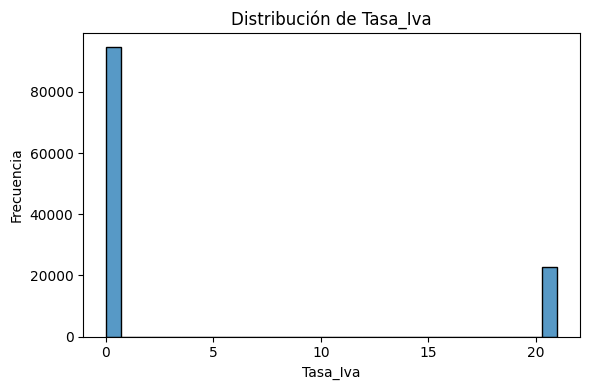

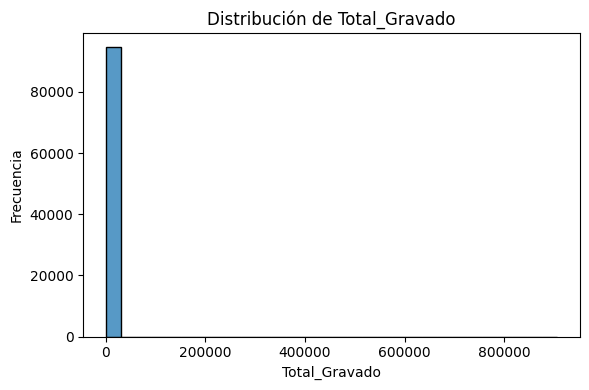

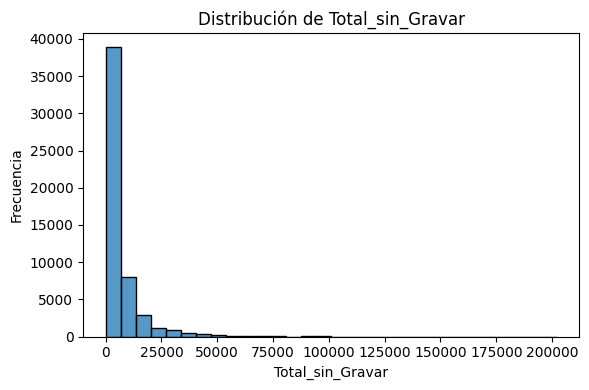

In [98]:
for col in final_numerical_variables.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

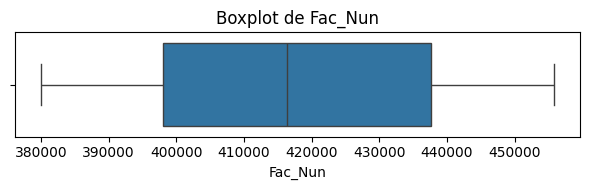

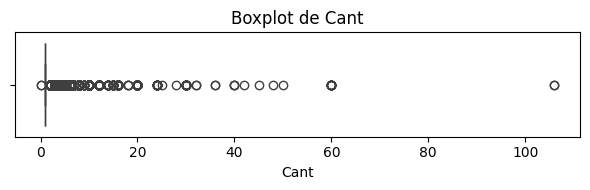

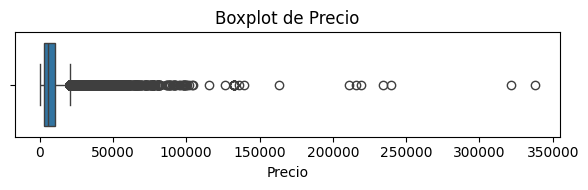

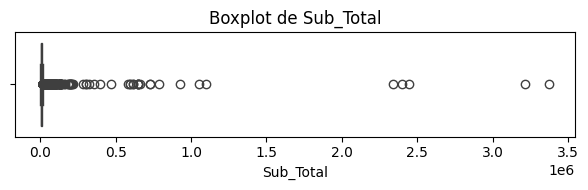

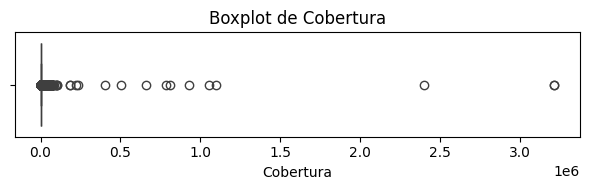

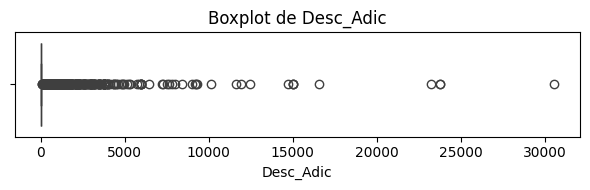

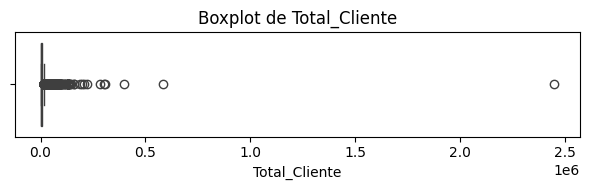

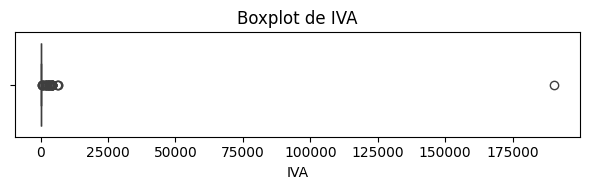

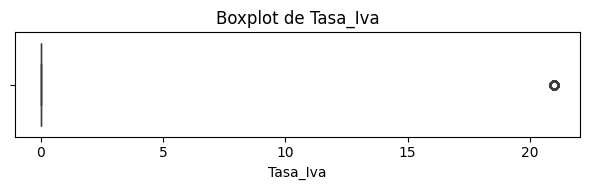

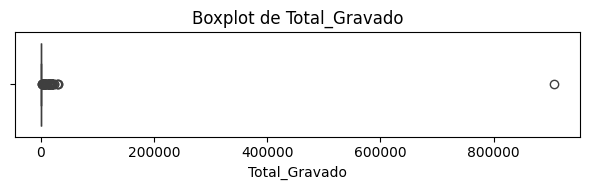

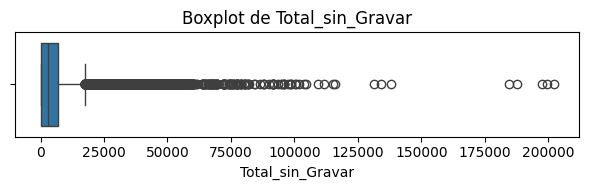

In [99]:
for col in final_numerical_variables.columns:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.tight_layout()
    plt.show()

In [100]:
df.loc[df['Cant'] > 50, ['Fecha', 'Fac_Tipo', 'Producto', 'Cant']]

,Fecha,Fac_Tipo,Producto,Cant
2190,2025-01-07 16:16:24,B,ENSURE ADVANCE LIQUIDO frutilla bot. x 220 ml,60
3001,2025-01-09 15:36:43,B,ENSURE PLUS vainilla env.x 220 ml,60
4521,2025-01-13 18:13:59,B,ENSURE ADVANCE LIQUIDO frutilla bot. x 220 ml,60
14340,2025-02-12 14:42:34,B,ENSURE PLUS vainilla env.x 220 ml,60
16565,2025-02-18 16:03:58,B,ENSURE PLUS FRUTILLA 220 ML,60
25463,2025-03-17 17:38:05,B,ENSURE ADVANCE LIQUIDO café botella x 220 ml,60
36775,2025-04-16 15:44:30,B,ENSURE PLUS vainilla env.x 220 ml,60
38911,2025-04-23 15:54:06,B,ENSURE PLUS frutilla env.x 220 ml,60
47946,2025-05-19 15:59:52,B,ENSURE PLUS frutilla env.x 220 ml,60
48730,2025-05-21 15:02:04,B,ENSURE PLUS vainilla env.x 220 ml,60


In [123]:
df.loc[df['Precio'] > 150000]

,Fecha,Fac_Tipo,Fac_Nun,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar,brand,form,product_name
19345,2025-02-27 18:23:52,B,391841,10,234001.0,NUTRILON PEPTI SYNEO lata x 400 g,2340010.0,FARMACIA,NaN,0.0,NaN,NaN,21,NaN,0.0,NUTRILON,Otros,nutrilon pepti syneo lata x 400 g
39950,2025-04-26 12:18:04,B,404495,10,239851.0,NUTRILON PEPTI SYNEO lata x 400 g,2398510.0,FARMACIA,2398421.0,0.0,89.0,NaN,21,NaN,0.0,NUTRILON,Otros,nutrilon pepti syneo lata x 400 g
41087,2025-04-30 09:19:16,A,405173,15,163200.0,BOTIQUIN METALICO PARA OBRA CON ACCESORIOS (un...,2448000.0,FARMACIA,0.0,0.0,2448000.0,NaN,21,NaN,0.0,BOTIQUIN,Otros,botiquin metalico para obra con accesorios unica
59070,2025-06-19 13:45:14,B,416525,10,321706.0,NEOCATE SYNEO env.x 400 g,3217060.0,FARMACIA,3217060.0,0.0,0.0,NaN,21,NaN,0.0,NEOCATE,Otros,neocate syneo envx 400 g
74143,2025-08-13 14:09:56,B,428983,10,337791.0,NEOCATE SYNEO env.x 400 g,3377910.0,FARMACIA,3217060.0,0.0,160850.0,NaN,21,NaN,0.0,NEOCATE,Otros,neocate syneo envx 400 g
80478,2025-09-01 18:56:44,B,432939,5,211052.0,NUTRILON SIN LACTOSA (NF) lata x 800 g,1055260.0,FARMACIA,1055260.0,0.0,0.0,NaN,21,NaN,0.0,NUTRILON,Otros,nutrilon sin lactosa nf lata x 800 g
88280,2025-09-25 15:42:04,B,437746,1,216000.0,SOLVENTE INDOLORO MONSERRAT Y ECLAIR sol.f.a.x...,9000.0,FARMACIA,0.0,0.0,9000.0,0.0,0,0.0,9000.0,SOLVENTE,Otros,solvente indoloro monserrat y eclair solfax 24...
96645,2025-10-20 18:50:54,B,442995,5,219494.0,NUTRILON SIN LACTOSA (NF) lata x 800 g,1097470.0,FARMACIA,1097470.0,0.0,0.0,190470.0,21,907000.0,0.0,NUTRILON,Otros,nutrilon sin lactosa nf lata x 800 g


In [101]:
df['Producto']

0         ACTRON PEDIATRICO 4% susp.oral x 100 ml
1                   AMOXIDAL 500 mg comp.rec.x 21
2                   AMOXIDAL 500 mg comp.rec.x 21
3               MUELITA FORTE GEL gel pomo x 10 g
4                         DIOXAFLEX B12 comp.x 20
                           ...                   
117410                            COLGATE (unica)
117411                  TAFIROL 1 G comp.ran.x 50
117412              CICATRICURE GEL Gel NF x 30 g
117413                  LOUTEN T colirio x 2.5 ml
117414               MADOPAR HBS 125 mg cáps.x 30
Name: Producto, Length: 117415, dtype: object

In [102]:
df['brand'] = df['Producto'].str.split().str[0]

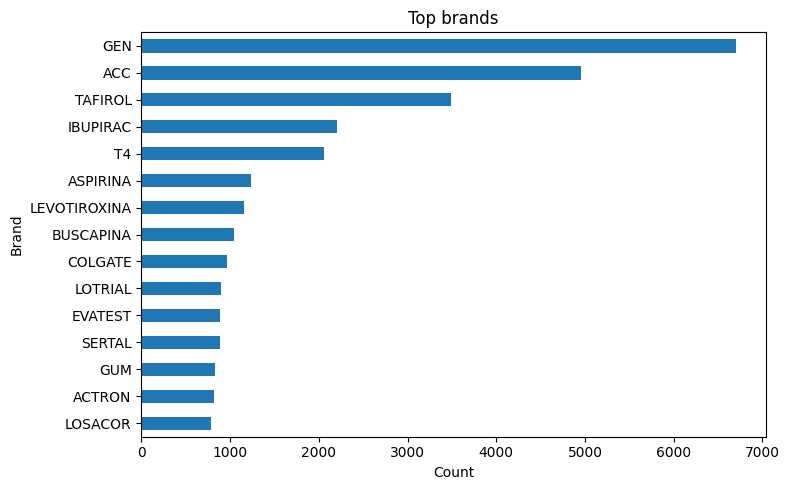

In [103]:
top_brands = df['brand'].value_counts().nlargest(15)

plt.figure(figsize=(8, 5))
top_brands.sort_values().plot(kind='barh')
plt.title('Top brands')
plt.xlabel('Count')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

In [104]:
def pharmacy_products(texto):
    if pd.isna(texto):
        return 'Unknown'
    
    texto = texto.lower()
    
    if 'comp' in texto:
        return 'Comprimido'
    elif 'gel' in texto:
        return 'Gel'
    elif 'susp' in texto:
        return 'Suspensión'
    elif 'colirio' in texto:
        return 'Colirio'
    elif 'jarabe' in texto:
        return 'Jarabe'
    elif 'caps' in texto or 'cáps' in texto:
        return 'Cápsula'
    else:
        return 'Otros'

df['form'] = df['Producto'].apply(pharmacy_products)

In [105]:
df['form']

0         Suspensión
1         Comprimido
2         Comprimido
3                Gel
4         Comprimido
             ...    
117410         Otros
117411    Comprimido
117412           Gel
117413       Colirio
117414       Cápsula
Name: form, Length: 117415, dtype: object

In [106]:
df['form'].value_counts()

form
Comprimido    52990
Otros         52861
Cápsula        7657
Gel            1796
Suspensión     1548
Colirio         427
Jarabe          135
Unknown           1
Name: count, dtype: int64

In [107]:
df.groupby('brand')['Precio'].mean().sort_values(ascending=False).head(15)

brand
NEOCATE        329748.500000
OMRON          136054.000000
SOLVENTE       112500.000000
REMIZERAL      104390.000000
DUTIDE          99687.000000
MAXIOSTENIL     99314.000000
VICHY           98187.000000
ACCU-CHEK       95726.727273
BIATRIX         92187.000000
SERETIDE        90992.000000
NEBULIZADOR     90000.000000
ASMABRON        82010.000000
SEROQUEL        81173.000000
ERYFOTONA       80593.000000
ENTRESTO        80556.000000
Name: Precio, dtype: float64

In [108]:
df.groupby('Producto')['Precio'].std().sort_values(ascending=False).head(10)

Producto
PARACETAMOL 1 GRAMO 1 g blíst.x 50 comp.x 8    51147.274245
MAMADERA (unica)                               35496.760416
CREMA (unica)                                  31965.012123
DORIXINA VL comp.x 20                          26443.398672
LRP MELA B3 10 30 ML SERUM                     16548.420000
NOXIBEL 30 mg comp.rec.x 30                    15533.721769
PRUNE (unica)                                  14707.821049
BOOS INTENSE ROSE EDP 90 ML FE                 13576.450199
TAFIROL comp.x 100                             12395.185571
SENS VAINILLA Y CASSIS EDT 100                 12020.815280
Name: Precio, dtype: float64

Los productos que más descuento reciben:

In [109]:
df.groupby('form')['Desc_Adic'].mean()

form
Colirio        0.000000
Comprimido     1.020042
Cápsula        8.836691
Gel            6.805876
Jarabe         0.000000
Otros         15.809393
Suspensión     0.000000
Unknown        0.000000
Name: Desc_Adic, dtype: float64

In [110]:
df['product_name'] = (df['Producto']
                       .str.lower()
                       .str.replace(r"[^a-z0-9 ]", "", regex=True))

In [111]:
df['product_name'].value_counts().head(30)

product_name
gen lp ibuprofeno blister 600 mg x 10                       1926
gen lp omeprazol blister 20 mg x 15                         1205
aspirina prevent compcubenterica x 50                       1150
tafirol 1g x 8 unica                                         870
tafirol 1 g compranx 50                                      699
osteodyn soloral x 2 ml                                      605
refenax gtsnasales x 25 ml                                   543
gen lp diclofenac blister 75 mg x 15                         530
gen lp diclofenac pridinol blister x 15                      488
acc lp gasa esteril no 5 caja 10 x 10                        473
corbis 5 mg comprecx 30                                      471
tafirol plus rapida accion cpsbl x 8                         471
alikal unica                                                 451
t4 montpellier 75 75 mcg compx 50                            446
acc lp tela antialergica 3m de 25 x 9 sracionador microp     438
t4 montpelli

In [112]:
df['Producto'].nunique()

7675

In [113]:
df['Producto'].dropna().drop_duplicates().sort_values().head(100)

88133       CHUP.MANZANITA(C/DIBUJO)T/SILIC.+3M RED - ES...
34267                                               (unica)
105693                                                    1
13978                                                   1 1
45585                         102 ANOS PLUS ANTIOXIDANTE 30
                                ...                        
29530     ACC LP TELA ANTIALERGICA 2.5 x 9 C/Racionador ...
55574     ACC LP TELA ANTIALERGICA 2.5 x 9 S/Racionador ...
32151     ACC LP TELA ANTIALERGICA 3M de 1.25 x 9 C/Raci...
32278     ACC LP TELA ANTIALERGICA 3M de 2.5 x 9 C/Racio...
104       ACC LP TELA ANTIALERGICA 3M de 2.5 x 9 S/Racio...
Name: Producto, Length: 100, dtype: object

In [114]:
unique_products.to_csv('unique_products.csv',
                       index=False,
                       encoding='utf-8')

NameError: name 'unique_products' is not defined

In [ ]:
def product_group(texto):
    if pd.isna(texto):
        return 'Unknown'
    texto = texto.lower()
    if 'amox' in texto or 'azitrom' in texto or 'ciproflox' in texto or 'aeroxi' in texto or 'cicli' in texto or 'cef' in texto:
        return 'Antibiótico'
    elif 'ibup' in texto or 'actron' in texto or 'paracet' in texto or 'alikal' in texto or 'fenaco' in texto or 'coxib' in texto or 'aspirina' in texto or 'dol' in texto:
        return 'Analgésico'
    elif 'magnes' in texto or 'acifol' in texto:
        return 'Suplemento'
    elif 'acemuk' in texto:
        return 'Mucolíticos'
    elif 'facia' in texto:
        return 'Cuidado facial'
    elif 'aeroti' in texto or 'aireal' in texto or 'alercas' in texto or 'alergitrat' in texto or 'alfacort' in texto or 'allegra' in texto or 'terol' in texto or 'rizina' in texto:
        return 'Antialergicos'
    elif 'agarol' in texto or 'agiolax' in texto:
        return 'Laxantes'
    elif 'agluci' in texto:
        return 'Medicamentos antidiabéticos'
    elif 'alernix' in texto:
        return 'Descongestionantes'
    elif 'aldactone' in texto:
        return 'Diuréticos'
    elif 'aliviafleb' in texto:
        return 'Vasculoprotectores'
    elif 'alpertan' in texto or 'sartan' in texto or 'pril' in texto or 'olol' in texto or 'dipino' in texto or 'estatina' in texto or 'atenolol' in texto or 'enalapril' in texto:
        return 'Salud Cardiovascular'
    elif 'alplax' in texto or 'alprazolam' in texto or 'diazepam' in texto or 'sertralina' in texto or 'fluoxetina' in texto:
        return 'Psicotrópicos'
    elif 'allopurinol' in texto or 'alopurinol' in texto:
        return 'Inhibidores de la xantina oxidasa'
    elif 'alerpriv' in texto:
        return 'Antigripales y Descongestionantes'
    elif 'almaximo' in texto or 'nafil' in texto or 'dalafil' in texto or 'sildenafil' in texto or 'tadalafil' in texto:
        return 'Salud Sexual'
    elif 'almohadilla' in texto or 'almohasilla' in texto or 'almphadilla' in texto or 'almohadillas' in texto:
        return 'Terapias físicas'
    elif 'oxigenada' in texto or 'oxi' in texto or 'alcohol' in texto:
        return 'Antisépticos'
    elif 'acimed' in texto or 'omep' in texto or 'pantoprazol' in texto or 'lanzoprazol' in texto:
        return 'Inhibidores'
    elif 'alumpak' in texto:
        return 'Antiácidos'
    elif 'alverin' in texto:
        return 'Antiespasmódicos'
    elif 'plax' in texto or 'pam' in texto or 'lam' in texto or 'tina' in texto or 'zepina' in texto or 'alplax' in texto or 'sertralina' in texto or 'clonazepam' in texto:
        return 'Salud Mental'
    elif 'alphagan' in texto or 'ofta' in texto or 'colirio' in texto or 'timolol' in texto or 'latanoprost' in texto:
        return 'Oftalmología'
    
    else:
        return 'Otros'
    
df['groups'] = df['Producto'].apply(product_group)

In [ ]:
df['groups']

0           Analgésico
1          Antibiótico
2          Antibiótico
3                Otros
4                Otros
              ...     
117410           Otros
117411           Otros
117412           Otros
117413    Oftalmología
117414           Otros
Name: groups, Length: 117415, dtype: object

In [ ]:
df['groups'].value_counts()

groups
Otros                                95988
Analgésico                            8733
Antisépticos                          2328
Antibiótico                           1796
Salud Cardiovascular                  1574
Inhibidores                           1321
Suplemento                            1104
Salud Mental                           828
Psicotrópicos                          748
Mucolíticos                            631
Oftalmología                           505
Antialergicos                          458
Cuidado facial                         322
Descongestionantes                     216
Salud Sexual                           180
Laxantes                               164
Inhibidores de la xantina oxidasa      156
Diuréticos                             116
Antigripales y Descongestionantes      105
Vasculoprotectores                      53
Terapias físicas                        44
Medicamentos antidiabéticos             23
Antiácidos                              14
Anti

In [ ]:
pharmaceutical_classifier = {
    'Salud Cardiovascular': ['alpertan', 'sartan', 'pril', 'olol', 'dipino', 'estatina', 'aspirina prevent', 'valsarfec', 
                             'tervalon', 'ateronova', 'torivas', 'aspirinetas', 'racorval',
        'atenolol', 'enalapril', 'losartan', 'amloc', 'cardio', 'aldactone', 'lotrial', 'diurex', 'rosustatin', 'rovastane', 'epistal', 'minuslip', 'carrier', 'meplar',
        'losacor', 'prinil', 'lipifen', 'ateroclar', 'aturen', 'daunlip', 'espironol', 'ateroclar', 'filten', 'bilip', 'bertel','nabila', 'corbis', 'diapresan'],
    'Salud Mental / Sistema Nervioso': ['pisono', 'alplax', 'alprazolam', 'clonazepam', 'diazepam', 'sertralina', 'fluoxetina', 'lexapro', 'psicoasten',
        'quetiapina', 'zepina', 'pam', 'lam', 'tina', 'asertral', 'clonagin', 'latrigin', 'paxon', 'risperin', 'psicotil', 'rivotril'],
    'Salud Digestiva': ['alumpak', 'alverin', 'almax', 'omeprazol', 'pantoprazol', 'lanzoprazol', 
        'aci-tip', 'agarol', 'buscapina', 'bagohepat', 'chofitol', 'crema de bismuto', 'oligoplex',
        'mylanta', 'taural', 'alikal', 'sertal', 'regulane', 'axiomat', 'loperamida', 'suerox'],
    'Salud Sexual / Urología': ['nafil', 'dalafil', 'almaximo', 'sildenafil', 'tadalafil'],
    'Oftalmología': ['alphagan', 'ofta', 'colirio', 'timolol', 'latanoprost', 'gotas', 'tobrex', 'soloftlmica', 'gatidex'],
    'Antibióticos': ['cilina', 'micina', 'floxacino', 'cicli', 'cef', 'amoxi', 'clavulanico', 'ceporexin', 'triamid', 'debril', 'mupax'],
    'Analgésicos / Antiinflamatorios': ['profeno', 'fenaco', 'coxib', 'paracetamol', 'aspirina', 'dol', 'clonixinato', 'mejoral', 'aziatop', 'aziatop', 'geniol',
                                        'meloxicam', 'dioxaflex', 'ketorolac', 'tafirol', 'naprux', 'diclofenac', 'ulcozol', 'prontal', 'vorpix'],
    'Salud Respiratoria / Antialérgicos': ['tadina', 'rizina', 'nasona', 'terol', 'ambroxol', 'mucol', 'frenadol', 'antigripal', 'ventolin', 
                                           'athos', 'ventolin', 'relvar', 'asmavitan', 'seretide'],
    'Antialérgicos': ['dexalergin', 'hexaler'],
    'Higiene y Cuidado Personal': ['shampoo', 'acondicionador', 'jabon', 'desodorante', 'axe', 'dove', 'colgate', 
        'pasta dental', 'cepillo', 'hilo dental', 'enjuague bucal', 'protector solar', 'neutrogena',
        'dermaglos', 'aderma', 'aveno', 'cerave', 'vichy', 'la roche', 'cicatricure', 'lactacyd',
        'asepxia', 'biferdil', 'capilatis', 'cutex', 'siempre libre', 'always', 'carefree', 'softpicks',
        'rexona', 'close', 'proxa', 'johnson', 'carey', 'pantene', 'nivea', 'softpicks', 'hinds'],
    'Accesorios y Dispositivos Médicos': ['pañal', 'huggies', 'pampers', 'toalla', 'algodon', 'jeringa', 'aguja', 'preservativo', 'condon', 'test', 'termometro', 'curitas', 'accesorio'],
    'Nutrición y Suplementos': ['102 anos', 'magnesio', 'vitamina', 'suplemento', 'ensure', 'pediasure', 
        'bagovit', 'centrum', 'berocca', 'supradyn', 'acifol', 'hierro', 'calcio', 'soloral', 'osteodyn',
        'omega 3', 'chia', 'colageno', 'artrostop', 'curflex', 'b12', 'becozym', 'forte'],
    'Diabetes y Endocrino': ['metformina', 'insulina', 'glibenclamida', 'levotiroxina', 't4', 'glucosa', 'glucogood'],
    'Material de Curación': ['guante', 'gasa', 'iruxol', 'iodopovidona', 'estéril', 'envase', 'antialérgica', 'tela', 'merthiolate'],
    'Cardiología / Antihipertensivos': ['simultan', 'veraten'],
    'Gripe': ['qura', 'rhinal', 'ventonil'],
    'Dermatología': ['paldar', 'megacistin', 'deralbine', 'vaselina', 'megacistin', 'empecid', 'cremtotal', 'hipoglós', 'diabet', 'betacort', 'hipoglós', 'factor', 'platsula'],
    'Ginecológico / Salud Femenina': ['fucsia', 'diva', 'colpofilin', 'vagisil', 'ovufem'],
    'Fragancia': ['cuore', 'pepas'],
    'Vascular': ['daflon'],
    'Urología': ['reduprost', 'urocont', 'prostoklar'],
    'Otorrino': ['meniex'],
}

In [ ]:
pharmaceutical_classifier = {
    'Salud Cardiovascular': ['alpertan', 'sartan', 'pril', 'olol', 'dipino', 'estatina', 
        'aspirina prevent', 'valsarfec', 'tervalon', 'ateronova', 
        'torivas', 'aspirinetas', 'racorval', 'atenolol', 'enalapril', 
        'losartan', 'amloc', 'cardio', 'aldactone', 'lotrial', 
        'diurex', 'rosustatin', 'rovastane', 'epistal', 'minuslip', 
        'carrier', 'meplar', 'losacor', 'prinil', 'lipifen', 'dilcoran',
        'ateroclar', 'aturen', 'daunlip', 'espironol', 'filten', 'pelmec', 'rosufec',
        'bilip', 'bertel', 'nabila', 'corbis', 'diapresan', 'ixium', 'azecar',
        'acalik', 'atenix', 'indalten', 'glioten', 'diocam', 'meridian', 'dipemina', 'valpex'],
    
    'Salud Mental / Sistema Nervioso': ['pisono', 'alplax', 'alprazolam', 'clonazepam', 'diazepam', 
        'sertralina', 'fluoxetina', 'lexapro', 'psicoasten', 'quetiapina', 'somit',
        'lamotrigina', 'zepam', 'latrigin', 'paxon', 'risperin', 'novo',
        'psicotil', 'rivotril', 'tiarix', 'ampliar', 'ultraneural', 'migral'],

    'Salud Digestiva': ['alumpak', 'alverin', 'almax', 'omeprazol', 'pantoprazol', 
        'lanzoprazol', 'aci-tip', 'agarol', 'buscapina', 'bagohepat',
        'chofitol', 'bismuto', 'oligoplex', 'mylanta', 'taural',
        'alikal', 'sertal', 'regulane', 'axiomat', 'loperamida', 
        'suerox', 'vorpix', 'aziatop', 'uvasal', 'rennie', 'hepatalgina'],

    'Salud Sexual / Urología': ['nafil', 'dalafil', 'sildenafil', 'tadalafil'],

    'Oftalmología': ['alphagan', 'ofta', 'colirio', 'timolol', 'latanoprost', 
        'gotas', 'tobrex', 'gatidex', 'soloftlmica', 'tobradex', 'sensu', 'natax', 'fotamicin'],

    'Antibióticos': ['cilina', 'micina', 'floxacino', 'cicli', 'cef', 'amoxi', 
        'clavulanico', 'ceporexin', 'triamid', 'debril'],

    'Antimicóticos': ['fluconazol', 'fangan'],

    'Analgésicos / Antiinflamatorios': ['profeno', 'fenaco', 'coxib', 'paracetamol', 'aspirina', 
        'dol', 'clonixinato', 'mejoral', 'geniol', 'meloxicam', 
        'dioxaflex', 'ketorolac', 'tafirol', 'naprux', 'diclofenac', 
        'prontal', 'ibu', 'evanol', 'diclomar', 'flogocox'],

    'Salud Respiratoria / Antialérgicos': ['tadina', 'rizina', 'nasona', 'terol', 'ambroxol', 'mucol', 
        'frenadol', 'antigripal', 'ventolin', 'athos', 'relvar', 'neumocort', 'nasal', 'lukast', 'aliviatos',
        'asmavitan', 'seretide', 'refenax', 'lidil'],

    'Antialérgicos': ['dexalergin', 'hexaler'],

    'Higiene y Cuidado Personal': ['shampoo', 'acondicionador', 'jabon', 'desodorante', 'axe', 
        'dove', 'colgate', 'pasta dental', 'cepillo', 'hilo dental', 'gillette',
        'enjuague bucal', 'protector solar', 'neutrogena', 'dermaglos', 'ensure',
        'aderma', 'aveno', 'cerave', 'vichy', 'la roche', 'cicatricure', 
        'lactacyd', 'asepxia', 'biferdil', 'capilatis', 'cutex', 
        'siempre libre', 'always', 'carefree', 'softpicks', 'rexona', 
        'close', 'proxa', 'johnson', 'carey', 'pantene', 'nivea', 'hinds',
        'labello', 'clear', 'corega', 'flossers', 'discos'],

    'Accesorios y Dispositivos Médicos': ['pañal', 'huggies', 'pampers', 'toalla', 'algodon', 'jeringa', 
        'aguja', 'preservativo', 'condon', 'test', 'termometro', 
        'curitas', 'accesorio', 'barbijo', 'maxx', 'broche', 'espermicida'],

    'Nutrición y Suplementos': ['magnesio', 'vitamina', 'suplemento', 'ensure', 'pediasure', 
        'bagovit', 'centrum', 'berocca', 'supradyn', 'acifol', 'hierro', 'nutrilon',
        'calcio', 'soloral', 'osteodyn', 'omega', 'chia', 'colageno', 'tapones',
        'artrostop', 'curflex', 'b12', 'becozym', 'redoxon', 'bernafolic', 'glucerna'],

    'Diabetes y Endocrino': ['metformina', 'insulina', 'glibenclamida', 'levotiroxina', 
        't4', 'glucosa', 'glucogood', 'forxiga'],

    'Material de Curación': ['guante', 'gasa', 'iruxol', 'iodopovidona', 'estéril', 'envase', 
        'antialérgica', 'tela', 'merthiolate', 'anestésico', 'ox'],

    'Gripe': ['qura', 'rhinal', 'ventonil'],

    'Dermatología': ['paldar', 'megacistin', 'deralbine', 'vaselina', 'empecid', 
        'cremtotal', 'hipoglos', 'diabet', 'betacort', 'factor', 'platsula', 'perpiel'],

    'Ginecológico / Salud Femenina': ['fucsia', 'diva', 'colpofilin', 'vagisil', 'ovufem', 'elektra', 'damsella'],

    'Fragancia': ['cuore', 'pepas', 'paco'],

    'Vascular': ['daflon'],

    'Urología': ['reduprost', 'urocont', 'prostoklar', 'duodart'],

    'Otorrino': ['meniex', 'otosan']
}

In [ ]:
def assign_category(name):
    name = str(name).lower()
    for category, words in pharmaceutical_classifier.items():
        for word in words:
            if word in name:
                return category
    return 'Otros'

In [ ]:
mask = df['groups'].isin(['Otros', 'Unknown'])

In [ ]:
df.loc[mask, 'groups'] = df.loc[mask, 'Producto'].apply(assign_category)

In [ ]:
print(df['groups'].value_counts())

groups
Otros                                 48702
Salud Cardiovascular                   9387
Analgésico                             8733
Salud Digestiva                        6750
Higiene y Cuidado Personal             6481
Analgésicos / Antiinflamatorios        6419
Material de Curación                   3621
Nutrición y Suplementos                2988
Salud Respiratoria / Antialérgicos     2878
Accesorios y Dispositivos Médicos      2515
Antisépticos                           2328
Salud Mental / Sistema Nervioso        2190
Dermatología                           1797
Antibiótico                            1796
Inhibidores                            1321
Suplemento                             1104
Oftalmología                            906
Salud Mental                            828
Antibióticos                            778
Psicotrópicos                           748
Mucolíticos                             631
Gripe                                   591
Urología                 

In [ ]:
df.loc[df['groups'] == 'Otros', ['product_name', 'groups']].head(40)

,product_name,groups
3,muelita forte gel gel pomo x 10 g,Otros
10,veraten ud 40 mg cpslibextx 30,Otros
11,asertral 50 mg compranx 30,Otros
27,simultan 160 mg comprecx 30,Otros
41,gum unica,Otros
59,ulcozol 20 20 mg compx 28,Otros
115,gum softpicks advanced 12 uni,Otros
135,platsula crx 30 g,Otros
142,dbi ap forte 1000 mg comprecx 60,Otros
159,idi unica,Otros
